In [1]:
import ast
from pathlib import Path
import gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import keras


from sklearn.metrics import f1_score, multilabel_confusion_matrix, roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer

from tensorflow.keras import mixed_precision, layers, Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, Add, MaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [2]:
BASE_DIR = Path.cwd()
if not (BASE_DIR / "X_train_processed.npy").exists():
    BASE_DIR = Path(r"D:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification")

TRAIN_AUDIO_PATH = BASE_DIR / "X_train_processed.npy"
VAL_AUDIO_PATH = BASE_DIR / "X_val_processed.npy"
TEST_AUDIO_PATH = BASE_DIR / "X_test_processed.npy"

TRAIN_CSV_PATH = BASE_DIR / "ptbxl_train.csv"
VAL_CSV_PATH = BASE_DIR / "ptbxl_val.csv"
TEST_CSV_PATH = BASE_DIR / "ptbxl_test.csv"

CSV_FEATURE_COLUMNS = [
    "age",
    "sex",
    "height",
    "weight",
    "validated_by_human",
    "height_missing",
    "weight_missing",
]

EXPECTED_SIGNAL_SHAPE = (5000, 12)
BATCH_SIZE = 6
PREDICT_BATCH_SIZE = 6        
EPOCHS = 30
LEARNING_RATE = 3e-4
METRIC_THRESHOLD = 0.5
THRESHOLD_SEARCH_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)
POS_WEIGHTS_PATH = BASE_DIR / "pos_weights.npy"
USE_POS_WEIGHTS = True
POS_WEIGHTS_MAX_CAP = 10.0   

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

policy_name = "mixed_float16" if gpus else "float32"
mixed_precision.set_global_policy(policy_name)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU, compute capability 8.6


In [3]:
def load_signal_npy(npy_path, mmap_mode="r"):
    signals = np.load(npy_path, allow_pickle=False, mmap_mode=mmap_mode)

    if signals.dtype != np.float32:
        signals = signals.astype(np.float32)

    if signals.ndim != 3 or tuple(signals.shape[1:]) != EXPECTED_SIGNAL_SHAPE:
        raise ValueError(
            f"Expected shape (N, {EXPECTED_SIGNAL_SHAPE[0]}, {EXPECTED_SIGNAL_SHAPE[1]}), got {signals.shape}"
        )

    return signals


def extract_codes_list(df):
    return df["scp_codes"].apply(lambda value: sorted(ast.literal_eval(value).keys()))


def build_feature_matrix(df, feature_cols):
    features = df[feature_cols].copy()

    bool_cols = features.select_dtypes(include=["bool"]).columns
    if len(bool_cols):
        features[bool_cols] = features[bool_cols].astype(np.float32)

    return features.astype(np.float32).to_numpy()


def assert_split_alignment(signals, features, labels, split_name):
    if len(signals) != len(features):
        raise ValueError(
            f"{split_name}: signals/features mismatch -> {len(signals)} vs {len(features)}"
        )

    if labels is not None and len(labels) != len(signals):
        raise ValueError(
            f"{split_name}: labels/signals mismatch -> {len(labels)} vs {len(signals)}"
        )


In [ ]:
def zero_pad_channels(x, out_channels, name=None):
    """
    Match shortcut channels to main path using zero-padding on channel dimension.
    This follows the spirit of the diagram's 'Zero out'.
    """
    in_channels = x.shape[-1]
    if in_channels is None:
        raise ValueError("Input channel dimension must be known at build time.")

    if in_channels == out_channels:
        return x

    if in_channels > out_channels:
        # If reduction ever happens, use 1x1 conv as a safe fallback.
        # In the shown architecture, channel count usually increases, not decreases.
        return layers.Conv1D(
            filters=out_channels,
            kernel_size=1,
            padding="same",
            use_bias=False,
            name=f"{name}_proj" if name else None,
        )(x)

    pad_channels = out_channels - in_channels
    return layers.Lambda(
        lambda t: tf.pad(t, paddings=[[0, 0], [0, 0], [0, pad_channels]]),
        name=f"{name}_zeropad" if name else None,
    )(x)


def first_residual_block(x, filters, kernel_size=16, dropout_rate=0.2, pool_size=2, name="first_block"):
    """
    Matches the first residual block in the figure:
    Conv -> BN -> Dropout -> Conv -> ReLU -> Add -> MaxPool
    """
    shortcut = x

    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
        name=f"{name}_conv1",
    )(x)
    y = layers.BatchNormalization(name=f"{name}_bn1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name}_drop1")(y)

    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
        name=f"{name}_conv2",
    )(y)
    y = layers.ReLU(name=f"{name}_relu2")(y)

    shortcut = zero_pad_channels(shortcut, filters, name=f"{name}_shortcut")
    y = layers.Add(name=f"{name}_add")([y, shortcut])

    y = layers.MaxPooling1D(
        pool_size=pool_size,
        strides=2,
        padding="same",
        name=f"{name}_pool",
    )(y)

    return y


def residual_block(x, filters, kernel_size=16, dropout_rate=0.2, do_pool=False, name="block"):
    """
    Matches the repeated block in the figure:
    BN -> ReLU -> Dropout -> Conv ->
    BN -> ReLU -> Dropout -> Conv ->
    Add -> (optional MaxPool)
    """
    shortcut = x

    y = layers.BatchNormalization(name=f"{name}_bn1")(x)
    y = layers.ReLU(name=f"{name}_relu1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name}_drop1")(y)
    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
        name=f"{name}_conv1",
    )(y)

    y = layers.BatchNormalization(name=f"{name}_bn2")(y)
    y = layers.ReLU(name=f"{name}_relu2")(y)
    y = layers.Dropout(dropout_rate, name=f"{name}_drop2")(y)
    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False,
        name=f"{name}_conv2",
    )(y)

    shortcut = zero_pad_channels(shortcut, filters, name=f"{name}_shortcut")
    y = layers.Add(name=f"{name}_add")([y, shortcut])

    if do_pool:
        y = layers.MaxPooling1D(
            pool_size=2,
            strides=2,
            padding="same",
            name=f"{name}_pool",
        )(y)

    return y


def build_ecg_resnet_like(
    input_shape=(5000, 12),
    num_labels=20,
    base_filters=64,
    stem_kernel_size=16,
    block_kernel_size=16,
    dropout_rate=0.2,
    num_blocks=15,
):
    """
    Builds an ECG 1D residual CNN close to the shown architecture.

    Input shape expected by Keras Conv1D:
        (timesteps, channels)
    For 12-lead ECG with length 5000:
        input_shape = (5000, 12)
    """

    inputs = layers.Input(shape=input_shape, name="ecg_input")

    # Stem: Conv -> BN -> ReLU
    x = layers.Conv1D(
        filters=base_filters,
        kernel_size=stem_kernel_size,
        padding="same",
        use_bias=False,
        name="stem_conv",
    )(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(name="stem_relu")(x)

    # First block from the figure
    x = first_residual_block(
        x,
        filters=base_filters,
        kernel_size=block_kernel_size,
        dropout_rate=dropout_rate,
        pool_size=2,
        name="first_residual_block",
    )

    # Repeated blocks: 1 <= i <= 15
    filters = base_filters
    for i in range(1, num_blocks + 1):
        # According to the figure, channel adjustment happens when i % 4 == 0
        if i % 4 == 0:
            filters *= 2

        # According to the figure, max pool happens when i % 2 == 0
        do_pool = (i % 2 == 0)

        x = residual_block(
            x,
            filters=filters,
            kernel_size=block_kernel_size,
            dropout_rate=dropout_rate,
            do_pool=do_pool,
            name=f"residual_block_{i}",
        )

    # Tail: BN -> ReLU
    x = layers.BatchNormalization(name="tail_bn")(x)
    x = layers.ReLU(name="tail_relu")(x)

    # The figure does not clearly show this, but practically we need an aggregation head
    x = layers.GlobalAveragePooling1D(name="global_avg_pool")(x)

    # Multi-label output:
    # Equivalent in practice to many Dense+Sigmoid heads shown in the figure
    outputs = layers.Dense(
        units=num_labels,
        activation="sigmoid",
        name="multi_label_output",
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name="ECG_Residual_CNN")
    return model

_ = build_ecg_resnet_like(
    input_shape=EXPECTED_SIGNAL_SHAPE,
    num_labels=20,
    base_filters=64,
    stem_kernel_size=16,
    block_kernel_size=16,
    dropout_rate=0.2,
    num_blocks=15,
)
_.summary()


Model: "ECG_Residual_CNN"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 5000, 12)]   0           []                               
                                                                                                  
 stem_conv (Conv1D)             (None, 5000, 64)     12288       ['ecg_input[0][0]']              
                                                                                                  
 stem_bn (BatchNormalization)   (None, 5000, 64)     256         ['stem_conv[0][0]']              
                                                                                                  
 stem_relu (ReLU)               (None, 5000, 64)     0           ['stem_bn[0][0]']                
                                                                                   

In [5]:
def make_weighted_binary_crossentropy(pos_weights):
    pos_weights = tf.convert_to_tensor(pos_weights, dtype=tf.float32)

    def weighted_binary_crossentropy(y_true, y_pred):
        y_true = tf.cast(y_true, y_pred.dtype)
        class_weights = tf.cast(pos_weights, y_pred.dtype)
        epsilon = tf.cast(tf.keras.backend.epsilon(), y_pred.dtype)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        positive_loss = y_true * tf.math.log(y_pred) * class_weights
        negative_loss = (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        return -tf.reduce_mean(positive_loss + negative_loss, axis=-1)

    weighted_binary_crossentropy.__name__ = "weighted_binary_crossentropy"
    return weighted_binary_crossentropy

In [6]:
def build_ecg_resnet_like_backbone(
    input_shape=(5000, 12),
    base_filters=64,
    stem_kernel_size=16,
    block_kernel_size=16,
    dropout_rate=0.2,
    num_blocks=15,
):
    """
    نفس build_ecg_resnet_like بالضبط لكن بدون Dense الأخيرة.
    بيرجع feature vector من GlobalAveragePooling1D.
    """
    inputs = layers.Input(shape=input_shape, name="ecg_input")

    x = layers.Conv1D(
        filters=base_filters,
        kernel_size=stem_kernel_size,
        padding="same",
        use_bias=False,
        name="stem_conv",
    )(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(name="stem_relu")(x)

    x = first_residual_block(
        x,
        filters=base_filters,
        kernel_size=block_kernel_size,
        dropout_rate=dropout_rate,
        pool_size=2,
        name="first_residual_block",
    )

    filters = base_filters
    for i in range(1, num_blocks + 1):
        if i % 4 == 0:
            filters *= 2
        do_pool = (i % 2 == 0)
        x = residual_block(
            x,
            filters=filters,
            kernel_size=block_kernel_size,
            dropout_rate=dropout_rate,
            do_pool=do_pool,
            name=f"residual_block_{i}",
        )

    x = layers.BatchNormalization(name="tail_bn")(x)
    x = layers.ReLU(name="tail_relu")(x)

    # ✅ نوقف هنا — بدون Dense sigmoid
    x = layers.GlobalAveragePooling1D(name="global_avg_pool")(x)

    return Model(inputs=inputs, outputs=x, name="ECG_ResNetLike_Backbone")


def build_multimodal_ecg_resnet_like(
    signal_shape,
    num_csv_features,
    num_classes,
    learning_rate=LEARNING_RATE,
    pos_weights=None,
    base_filters=64,
    num_blocks=15,
    dropout_rate=0.2,
):
    signal_input = Input(shape=signal_shape, dtype=tf.float32, name="signal_input")
    csv_input    = Input(shape=(num_csv_features,), dtype=tf.float32, name="csv_input")

    # ✅ الموديل الكبير كـ backbone
    backbone = build_ecg_resnet_like_backbone(
        input_shape=signal_shape,
        base_filters=base_filters,
        num_blocks=num_blocks,
        dropout_rate=dropout_rate,
    )
    signal_features = backbone(signal_input)  # shape: (batch, filters_last)

    # فرع الـ CSV
    csv_features = Dense(64, activation="relu", dtype="float32", name="csv_dense1")(csv_input)
    csv_features = Dropout(0.15, name="csv_dropout1")(csv_features)
    csv_features = Dense(32, activation="relu", dtype="float32", name="csv_dense2")(csv_features)

    # Fusion
    merged = Concatenate(name="fusion")([signal_features, csv_features])

    # Classification head
    x = Dense(512, activation="relu", dtype="float32", name="head_dense1")(merged)
    x = Dropout(0.25, name="head_dropout1")(x)
    x = Dense(256, activation="relu", dtype="float32", name="head_dense2")(x)
    x = Dropout(0.20, name="head_dropout2")(x)

    output = Dense(num_classes, activation="sigmoid", dtype="float32", name="output")(x)

    model = Model(
        inputs=[signal_input, csv_input],
        outputs=output,
        name="Multimodal_ECG_ResNetLike"
    )

    loss_fn = (
        make_weighted_binary_crossentropy(pos_weights)
        if pos_weights is not None
        else "binary_crossentropy"
    )

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=[
            tf.keras.metrics.AUC(name="pr_auc", multi_label=True, curve="PR"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            tf.keras.metrics.AUC(name="auc", multi_label=True),

        ],
    )
    return model

In [7]:
def summarize_history(history):
    history_df = pd.DataFrame(history.history)
    print("Last epoch metrics:")
    print(history_df.tail(1).round(4).to_string(index=False))

    if "val_auc" in history_df.columns:
        best_epoch = int(history_df["val_auc"].idxmax()) + 1
        best_val_auc = float(history_df["val_auc"].max())
        print(f"Best validation AUC epoch: {best_epoch}")
        print(f"Best validation AUC: {best_val_auc:.4f}")

    return history_df


def plot_history(history_df):
    if history_df.empty:
        print("No history to plot.")
        return None

    epochs = range(1, len(history_df) + 1)
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    if "loss" in history_df.columns:
        axes[0].plot(epochs, history_df["loss"], marker="o", label="loss")
    if "val_loss" in history_df.columns:
        axes[0].plot(epochs, history_df["val_loss"], marker="o", label="val_loss")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if "binary_accuracy" in history_df.columns:
        axes[1].plot(epochs, history_df["binary_accuracy"], marker="o", label="binary_accuracy")
    if "val_binary_accuracy" in history_df.columns:
        axes[1].plot(epochs, history_df["val_binary_accuracy"], marker="o", label="val_binary_accuracy")
    axes[1].set_title("Binary Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if "auc" in history_df.columns:
        axes[2].plot(epochs, history_df["auc"], marker="o", label="auc")
    if "val_auc" in history_df.columns:
        axes[2].plot(epochs, history_df["val_auc"], marker="o", label="val_auc")
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def safe_multilabel_auc(y_true, y_score, average):
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    valid_columns = []
    for i in range(y_true.shape[1]):
        positive_count = y_true[:, i].sum()
        if 0 < positive_count < len(y_true):
            valid_columns.append(i)

    if not valid_columns:
        return np.nan

    return float(roc_auc_score(y_true[:, valid_columns], y_score[:, valid_columns], average=average))


def batched_multimodal_predict(model, x_signal, x_csv, batch_size=None):
    """بتقييم الموديل على batches صغيرة لتجنب MemoryError"""
    if batch_size is None:
        batch_size = PREDICT_BATCH_SIZE   # <<< استخدام batch أصغر

    if len(x_signal) != len(x_csv):
        raise ValueError(f"signals/features mismatch -> {len(x_signal)} vs {len(x_csv)}")

    predictions = []
    for start in range(0, len(x_signal), batch_size):
        end = min(start + batch_size, len(x_signal))
        signal_batch = np.array(x_signal[start:end], dtype=np.float32)
        csv_batch = np.array(x_csv[start:end], dtype=np.float32)
        batch_prediction = model([signal_batch, csv_batch], training=False).numpy()
        predictions.append(batch_prediction)

        # تحرير الذاكرة بعد كل batch
        del signal_batch, csv_batch
        gc.collect()

    if not predictions:
        return np.empty((0, model.output_shape[-1]), dtype=np.float32)

    return np.vstack(predictions).astype(np.float32)


def show_multilabel_confusion_matrices(y_true, y_pred, class_names, top_k=9, label_indices=None):
    y_true = np.array(y_true, dtype=np.int32)
    y_pred = np.array(y_pred, dtype=np.int32)
    matrices = multilabel_confusion_matrix(y_true, y_pred)
    support = y_true.sum(axis=0)

    if label_indices is None:
        label_indices = np.argsort(-support)[:top_k]

    label_indices = list(label_indices)
    if not label_indices:
        return {}

    cols = min(3, len(label_indices))
    rows = int(np.ceil(len(label_indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    results = {}
    for plot_index, idx in enumerate(label_indices):
        label_name = str(class_names[idx])
        table = pd.DataFrame(
            matrices[idx],
            index=["Actual 0", "Actual 1"],
            columns=["Pred 0", "Pred 1"],
        )
        sns.heatmap(table, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[plot_index])
        axes[plot_index].set_title(f"{label_name} (support={int(support[idx])})")
        results[label_name] = table

    for i in range(len(label_indices), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

    return results


def evaluate_multimodal_predictions(y_true, y_score, split_name, threshold=METRIC_THRESHOLD):
    y_true = np.array(y_true, dtype=np.float32)
    y_score = np.array(y_score, dtype=np.float32)
    threshold_array = np.array(threshold, dtype=np.float32)
    y_pred = (y_score >= threshold_array).astype(np.float32)

    return {
        "split": split_name,
        "threshold": float(threshold_array.mean()) if threshold_array.ndim else float(threshold_array),
        "threshold_kind": "per_class" if threshold_array.ndim else "global",
        "binary_accuracy": float((y_pred == y_true).mean()),
        "f1_micro": float(f1_score(y_true, y_pred, average="micro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "auc_micro": safe_multilabel_auc(y_true, y_score, average="micro"),
        "auc_macro": safe_multilabel_auc(y_true, y_score, average="macro"),
    }


def tune_global_threshold(y_true, y_score, grid=THRESHOLD_SEARCH_GRID, optimize_metric="f1_macro"):
    best_metrics = None
    for threshold in np.array(grid, dtype=np.float32):
        metrics = evaluate_multimodal_predictions(y_true, y_score, "validation", threshold=float(threshold))
        if best_metrics is None or metrics[optimize_metric] > best_metrics[optimize_metric]:
            best_metrics = metrics
    return best_metrics


def tune_per_class_thresholds(y_true, y_score, class_names=None, grid=THRESHOLD_SEARCH_GRID):
    y_true = np.array(y_true, dtype=np.float32)
    y_score = np.array(y_score, dtype=np.float32)
    thresholds = np.full(y_true.shape[1], METRIC_THRESHOLD, dtype=np.float32)
    rows = []

    for idx in range(y_true.shape[1]):
        best_threshold = float(METRIC_THRESHOLD)
        best_f1 = -1.0
        label_true = y_true[:, idx]
        label_score = y_score[:, idx]

        for threshold in np.array(grid, dtype=np.float32):
            label_pred = (label_score >= threshold).astype(np.float32)
            label_f1 = float(f1_score(label_true, label_pred, zero_division=0))
            if label_f1 > best_f1:
                best_f1 = label_f1
                best_threshold = float(threshold)

        thresholds[idx] = best_threshold
        label_name = class_names[idx] if class_names is not None else idx
        rows.append({
            "label": str(label_name),
            "support": int(label_true.sum()),
            "threshold": best_threshold,
            "best_label_f1": best_f1,
        })

    thresholds_df = pd.DataFrame(rows).sort_values(["support", "threshold", "label"], ascending=[False, True, True]).reset_index(drop=True)
    return thresholds, thresholds_df


def evaluate_multimodal_split(model, x_signal, x_csv, y_true, split_name, threshold=METRIC_THRESHOLD):
    y_score = batched_multimodal_predict(model, x_signal, x_csv, batch_size=BATCH_SIZE)
    return evaluate_multimodal_predictions(y_true, y_score, split_name, threshold=threshold)


In [8]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

X_train_signal = load_signal_npy(TRAIN_AUDIO_PATH)
X_val_signal = load_signal_npy(VAL_AUDIO_PATH)
X_test_signal = load_signal_npy(TEST_AUDIO_PATH)

X_train_csv = build_feature_matrix(train_df, CSV_FEATURE_COLUMNS)
X_val_csv = build_feature_matrix(val_df, CSV_FEATURE_COLUMNS)
X_test_csv = build_feature_matrix(test_df, CSV_FEATURE_COLUMNS)

mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(extract_codes_list(train_df)).astype(np.float32)
y_val = mlb.transform(extract_codes_list(val_df)).astype(np.float32)
y_test = mlb.transform(extract_codes_list(test_df)).astype(np.float32)

assert_split_alignment(X_train_signal, X_train_csv, y_train, "train")
assert_split_alignment(X_val_signal, X_val_csv, y_val, "val")
assert_split_alignment(X_test_signal, X_test_csv, y_test, "test")

SIGNAL_SHAPE = X_train_signal.shape[1:]
NUM_CLASSES = y_train.shape[1]

POS_WEIGHTS = None
if USE_POS_WEIGHTS:
    if not POS_WEIGHTS_PATH.exists():
        raise FileNotFoundError(f"pos_weights file not found: {POS_WEIGHTS_PATH}")

    raw_pos_weights = np.load(POS_WEIGHTS_PATH).astype(np.float32)
    if raw_pos_weights.shape != (NUM_CLASSES,):
        raise ValueError(f"Expected pos_weights shape ({NUM_CLASSES},), got {raw_pos_weights.shape}")

    # === التعديل الأساسي: تقليل الـ pos_weights ===
    # الأصلي: median=50, max=50 → مبالغ فيه جداً
    # الجديد: sqrt ثم clip بحد أقصى POS_WEIGHTS_MAX_CAP
    POS_WEIGHTS = np.clip(np.sqrt(raw_pos_weights), 1.0, POS_WEIGHTS_MAX_CAP)

    print("Raw pos_weights summary:", {
        "min": round(float(raw_pos_weights.min()), 4),
        "median": round(float(np.median(raw_pos_weights)), 4),
        "max": round(float(raw_pos_weights.max()), 4),
    })
    print("Adjusted pos_weights summary:", {
        "min": round(float(POS_WEIGHTS.min()), 4),
        "median": round(float(np.median(POS_WEIGHTS)), 4),
        "max": round(float(POS_WEIGHTS.max()), 4),
    })
else:
    print("Using standard binary_crossentropy without pos_weights.")

print("Train signal:", X_train_signal.shape, X_train_signal.dtype)
print("Val signal:", X_val_signal.shape, X_val_signal.dtype)
print("Test signal:", X_test_signal.shape, X_test_signal.dtype)
print("Train CSV:", X_train_csv.shape, X_train_csv.dtype)
print("Labels:", NUM_CLASSES)
print("classes:", mlb.classes_[:].tolist())

Raw pos_weights summary: {'min': 1.0, 'median': 50.0, 'max': 50.0}
Adjusted pos_weights summary: {'min': 1.0, 'median': 7.0711, 'max': 7.0711}
Train signal: (17418, 5000, 12) float32
Val signal: (2183, 5000, 12) float32
Test signal: (2198, 5000, 12) float32
Train CSV: (17418, 7) float32
Labels: 71
classes: ['1AVB', '2AVB', '3AVB', 'ABQRS', 'AFIB', 'AFLT', 'ALMI', 'AMI', 'ANEUR', 'ASMI', 'BIGU', 'CLBBB', 'CRBBB', 'DIG', 'EL', 'HVOLT', 'ILBBB', 'ILMI', 'IMI', 'INJAL', 'INJAS', 'INJIL', 'INJIN', 'INJLA', 'INVT', 'IPLMI', 'IPMI', 'IRBBB', 'ISCAL', 'ISCAN', 'ISCAS', 'ISCIL', 'ISCIN', 'ISCLA', 'ISC_', 'IVCD', 'LAFB', 'LAO/LAE', 'LMI', 'LNGQT', 'LOWT', 'LPFB', 'LPR', 'LVH', 'LVOLT', 'NDT', 'NORM', 'NST_', 'NT_', 'PAC', 'PACE', 'PMI', 'PRC(S)', 'PSVT', 'PVC', 'QWAVE', 'RAO/RAE', 'RVH', 'SARRH', 'SBRAD', 'SEHYP', 'SR', 'STACH', 'STD_', 'STE_', 'SVARR', 'SVTAC', 'TAB_', 'TRIGU', 'VCLVH', 'WPW']


In [9]:
model = build_multimodal_ecg_resnet_like(
    signal_shape=SIGNAL_SHAPE,
    num_csv_features=X_train_csv.shape[1],
    num_classes=NUM_CLASSES,
    pos_weights=POS_WEIGHTS,
    base_filters=32,
    num_blocks=15,
    dropout_rate=0.2,
)

model.summary()

Model: "Multimodal_ECG_ResNetLike"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 csv_input (InputLayer)         [(None, 7)]          0           []                               
                                                                                                  
 csv_dense1 (Dense)             (None, 64)           512         ['csv_input[0][0]']              
                                                                                                  
 signal_input (InputLayer)      [(None, 5000, 12)]   0           []                               
                                                                                                  
 csv_dropout1 (Dropout)         (None, 64)           0           ['csv_dense1[0][0]']             
                                                                          

In [ ]:
callbacks = [
    ModelCheckpoint(
        BASE_DIR / "ecg_resnetlike_multimodal_best.weights.h5",
        monitor="val_pr_auc",    
        mode="max",           
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_pr_auc",    
        mode="max",            
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_pr_auc",      
        factor=0.5,
        patience=3,
        mode="max",           
        verbose=1,
    ),
]

In [ ]:
history = model.fit(
    [X_train_signal, X_train_csv],
    y_train,
    validation_data=([X_val_signal, X_val_csv], y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)



Epoch 1/100
2903/2903 [==============================] - ETA: 0s - loss: 0.2563 - pr_auc: 0.1161 - precision: 0.5174 - recall: 0.5374 - binary_accuracy: 0.9619 - auc: 0.7439
Epoch 1: val_pr_auc improved from -inf to 0.20138, saving model to d:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification\ecg_resnetlike_multimodal_best.weights.h5
2903/2903 [==============================] - 414s 138ms/step - loss: 0.2563 - pr_auc: 0.1161 - precision: 0.5174 - recall: 0.5374 - binary_accuracy: 0.9619 - auc: 0.7439 - val_loss: 0.2302 - val_pr_auc: 0.2014 - val_precision: 0.5611 - val_recall: 0.6108 - val_binary_accuracy: 0.9660 - val_auc: 0.8139 - lr: 3.0000e-04
Epoch 2/100
2903/2903 [==============================] - ETA: 0s - loss: 0.2086 - pr_auc: 0.1870 - precision: 0.5549 - recall: 0.6408 - binary_accuracy: 0.9655 - auc: 0.8395
Epoch 2: val_pr_auc improved from 0.20138 to 0.24611, saving model to d:\AOU-Graduation-Project\BioIntellect\AI\ECG\App\classification\ecg_resnetlike_multimod

Last epoch metrics:
  loss  pr_auc  precision  recall  binary_accuracy   auc  val_loss  val_pr_auc  val_precision  val_recall  val_binary_accuracy  val_auc     lr
0.0931  0.5731     0.6789  0.8587           0.9784 0.981    0.1753       0.352         0.6004      0.7788                0.971   0.8791 0.0001
Best validation AUC epoch: 11
Best validation AUC: 0.9190


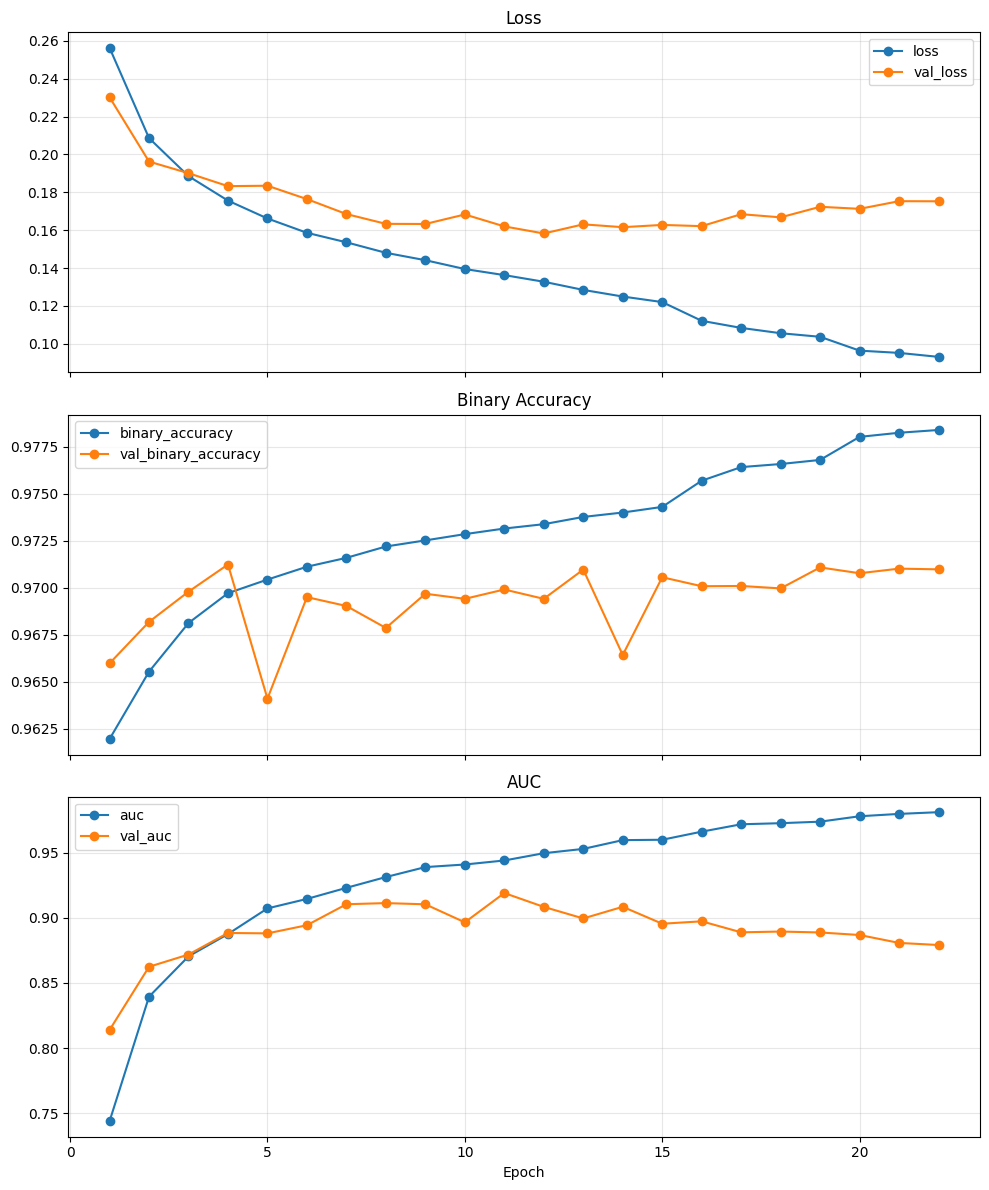

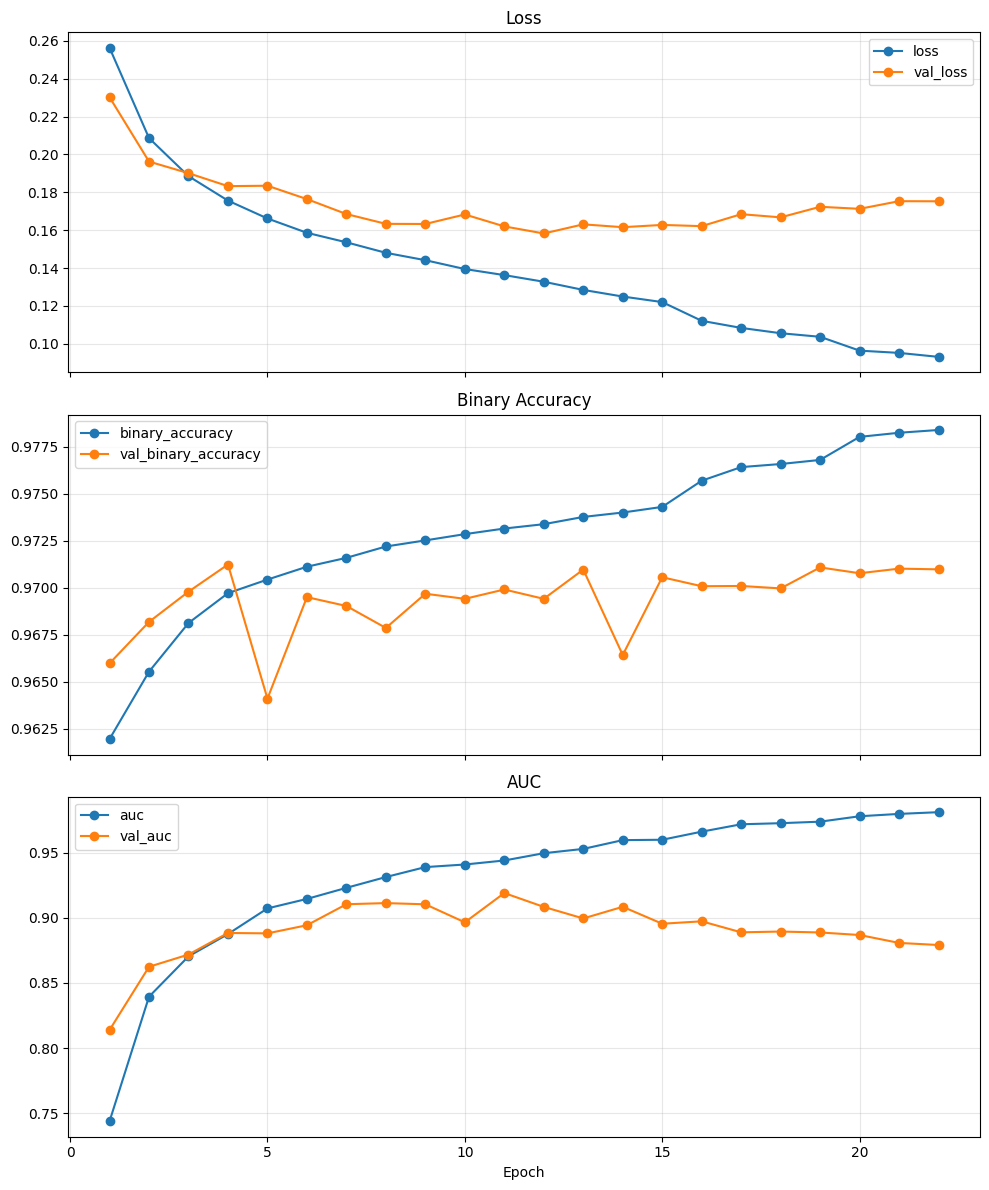

In [12]:
history_df = summarize_history(history)
plot_history(history_df)

In [13]:
print("=" * 60)
print("🔍 Step 1: Generating predictions on validation set...")
print("=" * 60)
val_score = batched_multimodal_predict(model, X_val_signal, X_val_csv)
gc.collect()

print("\n" + "=" * 60)
print("🔍 Step 2: Evaluating with FIXED threshold (0.5)...")
print("=" * 60)
fixed_metrics = evaluate_multimodal_predictions(y_val, val_score, "validation_fixed_0.5", threshold=METRIC_THRESHOLD)
print(pd.DataFrame([fixed_metrics]).set_index("split").round(4).to_string())

print("\n" + "=" * 60)
print("🔍 Step 3: Tuning GLOBAL threshold...")
print("=" * 60)
best_global_metrics = tune_global_threshold(y_val, val_score)
best_global_threshold = best_global_metrics["threshold"]
print(f"Best global threshold: {best_global_threshold}")
print(pd.DataFrame([best_global_metrics]).set_index("split").round(4).to_string())

print("\n" + "=" * 60)
print("🔍 Step 4: Tuning PER-CLASS thresholds...")
print("=" * 60)
per_class_thresholds, thresholds_df = tune_per_class_thresholds(
    y_val, val_score, class_names=mlb.classes_
)
print("\nPer-class thresholds:")
print(thresholds_df.to_string(index=False))

per_class_val_metrics = evaluate_multimodal_predictions(
    y_val, val_score, "validation_per_class", threshold=per_class_thresholds
)
print("\nValidation metrics with per-class thresholds:")
print(pd.DataFrame([per_class_val_metrics]).set_index("split").round(4).to_string())

print("\n" + "=" * 60)
print("🔍 Step 5: Generating predictions on TEST set...")
print("=" * 60)
test_score = batched_multimodal_predict(model, X_test_signal, X_test_csv)
gc.collect()

print("\n" + "=" * 60)
print("📊 Step 6: Final TEST evaluation — comparison")
print("=" * 60)

# مقارنة: threshold ثابت vs global tuned vs per-class
test_fixed = evaluate_multimodal_predictions(y_test, test_score, "test_fixed_0.5", threshold=0.5)
test_global = evaluate_multimodal_predictions(y_test, test_score, f"test_global_{best_global_threshold}", threshold=best_global_threshold)
test_per_class = evaluate_multimodal_predictions(y_test, test_score, "test_per_class", threshold=per_class_thresholds)

comparison_df = pd.DataFrame([test_fixed, test_global, test_per_class]).set_index("split").round(4)
print("\n🏆 Test Results Comparison:")
print(comparison_df.to_string())
print("\n✅ Per-class thresholds should give the BEST F1 scores!")

# حفظ الـ per-class thresholds للاستخدام في الـ production
np.save(BASE_DIR / "per_class_thresholds.npy", per_class_thresholds)
print(f"\n💾 Per-class thresholds saved to: {BASE_DIR / 'per_class_thresholds.npy'}")


🔍 Step 1: Generating predictions on validation set...

🔍 Step 2: Evaluating with FIXED threshold (0.5)...
                      threshold threshold_kind  binary_accuracy  f1_micro  f1_macro  f1_weighted  auc_micro  auc_macro
split                                                                                                                 
validation_fixed_0.5        0.5         global           0.9701    0.6726    0.3478       0.6975     0.9759     0.9288

🔍 Step 3: Tuning GLOBAL threshold...
Best global threshold: 0.5
            threshold threshold_kind  binary_accuracy  f1_micro  f1_macro  f1_weighted  auc_micro  auc_macro
split                                                                                                       
validation        0.5         global           0.9701    0.6726    0.3478       0.6975     0.9759     0.9288

🔍 Step 4: Tuning PER-CLASS thresholds...

Per-class thresholds:
  label  support  threshold  best_label_f1
     SR     1670       0.38       0.9